# Take the Sequencing reads from yeast Sort 2 and compute AD activities

In [1]:
import localcider
import protfasta
import glob
import pandas as pd
import numpy as np
import re
import scipy
from scipy import stats
import matplotlib.pyplot as plt
from collections import defaultdict 
from Bio.Seq import Seq

## READ ME: this is the main thing to change
# this is the list of sequence that we will try to make perfect matches to.

masterDF_original = pd.read_csv('../Data/DesignFiles/DF_SOG1.csv') # change me
masterDF_original['Barcode'] = masterDF_original.ArrayDNA # not using barcodes, so "barcode" = ArrayDNA

print(masterDF_original.shape)
masterDF_original = masterDF_original.drop_duplicates()
masterDF_original.shape

(1126, 94)


(1126, 94)

In [2]:
DesignedBCs = list(masterDF_original.ArrayDNA)

In [3]:
masterDF_original

,Column1,ADseq,I,A,A1,B,B1,B2,C,C1,...,CountR,CountS,CountT,CountV,CountW,CountY,Aromatics,fullDNA,ArrayDNA,Barcode
0,0,MAGRSWLIDSNRIATKIMSASASSDPRQVVWKSNPSRHCP,1.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,...,4,8,1,2,2,0,2,GCGGGCTCTACTTCATCGGCTAGCATGGCTGGTAGATCTTGGTTGA...,ATGGCTGGTAGATCTTGGTTGATTGATTCTAATAGAATTGCTACTA...,ATGGCTGGTAGATCTTGGTTGATTGATTCTAATAGAATTGCTACTA...
1,1,NRIATKIMSASASSDPRQVVWKSNPSRHCPKCQHVIDNSD,1.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,...,3,7,1,3,1,0,1,GCGGGCTCTACTTCATCGGCTAGCAATAGAATTGCTACTAAGATTA...,AATAGAATTGCTACTAAGATTATGTCTGCTTCTGCTTCTTCTGATC...,AATAGAATTGCTACTAAGATTATGTCTGCTTCTGCTTCTTCTGATC...
2,2,SASSDPRQVVWKSNPSRHCPKCQHVIDNSDVVDDWPGLPR,1.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,...,3,6,0,5,2,0,2,GCGGGCTCTACTTCATCGGCTAGCTCTGCTTCTTCTGATCCAAGAC...,TCTGCTTCTTCTGATCCAAGACAAGTTGTTTGGAAATCTAATCCAT...,TCTGCTTCTTCTGATCCAAGACAAGTTGTTTGGAAATCTAATCCAT...
3,3,WKSNPSRHCPKCQHVIDNSDVVDDWPGLPRGVKFDPSDPE,1.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,...,2,4,0,4,2,0,3,GCGGGCTCTACTTCATCGGCTAGCTGGAAATCTAATCCATCTAGAC...,TGGAAATCTAATCCATCTAGACATTGTCCTAAATGTCAACATGTTA...,TGGAAATCTAATCCATCTAGACATTGTCCTAAATGTCAACATGTTA...
4,4,KCQHVIDNSDVVDDWPGLPRGVKFDPSDPEIIWHLLAKSG,1.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,...,1,3,0,4,2,0,3,GCGGGCTCTACTTCATCGGCTAGCAAATGTCAACATGTTATTGATA...,AAATGTCAACATGTTATTGATAATTCTGATGTTGTTGATGATTGGC...,AAATGTCAACATGTTATTGATAATTCTGATGTTGTTGATGATTGGC...
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1121,1121,PPTDVSLGDELHLDGEDVAMAHADALDDFDLDMLGDGDSP,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0,2,1,2,0,0,1,GCGGGCTCTACTTCATCGGCTAGCCCACCAACTGATGTTTCTTTGG...,CCACCAACTGATGTTTCTTTGGGTGATGAATTGCATTTGGATGGTG...,CCACCAACTGATGTTTCTTTGGGTGATGAATTGCATTTGGATGGTG...
1122,1122,PPTDVSAGDEAHADGEDVAMAHADAADDFDADMAGDGDSP,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0,2,1,2,0,0,1,GCGGGCTCTACTTCATCGGCTAGCCCACCAACTGATGTTTCTGCTG...,CCACCAACTGATGTTTCTGCTGGTGATGAAGCTCATGCTGATGGTG...,CCACCAACTGATGTTTCTGCTGGTGATGAAGCTCATGCTGATGGTG...
1123,1123,GPKTPEISSMLVNNNEASFVEETNAAKKLKPNSDESDDLM,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0,5,2,2,0,0,1,GCGGGCTCTACTTCATCGGCTAGCGGTCCTAAGACTCCAGAAATTT...,GGTCCTAAGACTCCAGAAATTTCTTCTATGTTGGTTAATAATAATG...,GGTCCTAAGACTCCAGAAATTTCTTCTATGTTGGTTAATAATAATG...
1124,1124,VVSSAPSSSCLDFLWEENNPDTLLIDTQWLEDIIMGDANK,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0,5,2,2,2,0,3,GCGGGCTCTACTTCATCGGCTAGCGTTGTTTCTTCTGCTCCATCTT...,GTTGTTTCTTCTGCTCCATCTTCTTCTTGTTTGGACTTCTTGTGGG...,GTTGTTTCTTCTGCTCCATCTTCTTCTTGTTTGGACTTCTTGTGGG...


In [4]:
def processReadCounts(ExpName,data_dir,BinValues,readthreshold,plothist=0,plotReadDepthHist=False):
    filelist = sorted(glob.glob(data_dir+'*.csv'))
    nBCs,columnNames = len(DesignedBCs),[]
    barcodecounts = np.zeros(shape=(nBCs,len(filelist)))# only perfect matches
    ExportDF = masterDF_original[['Barcode']]
    
    for index, filename in enumerate(filelist):
        myfile = open(filename,'r')
        currentFile = myfile.readlines()
        BCcountsDict = defaultdict(int)
        BCmatchCounter, BCmatchReadCounter, TotalReadCounter = 0,0,0
        SeqAbundances = []
        print('%s has %i unique sequences' %(filename, len(currentFile)))
        for line in currentFile:
            count, seq = line.split(',')
            seq = seq.strip()
            count = int(count)
            SeqAbundances.append(count)
            TotalReadCounter += count
            if len(seq) == 120: #only use reads that have right length after the GREP
                BC = seq#[5:-6]
                if BC in DesignedBCs:

                    if count >0:
                        BCmatchCounter += 1
                        BCmatchReadCounter += count
                    BCcountsDict[BC] += count # only add the BC to the dictionary if it is above the threshold
        fractionReadsMatching = 100.0* BCmatchReadCounter/TotalReadCounter
        print( '%i reads with %i matching designed BCs' %(TotalReadCounter,BCmatchReadCounter))
        print( '%i BC matches containing %.1f percent of reads' % (BCmatchCounter, fractionReadsMatching))
        #########
        # make a histogram of the read depth for checking sequening quality
        if plotReadDepthHist==True:
            SeqAbundances =np.array(SeqAbundances)
            plt.subplot(1,2,1)
            plt.hist(SeqAbundances,50)
            plt.xlabel('Read Counts')
            plt.plot([readthreshold,readthreshold],[0,10000])
            plt.subplot(1,2,2)
            SeqAbundances = SeqAbundances[SeqAbundances>0]
            plt.hist(np.log2(SeqAbundances),50)
            plt.plot([np.log2(readthreshold),np.log2(readthreshold)],[0,300])
            plt.xlabel('log2(Read Counts)')
            plt.show()
        # take the count Dictionary and make it into a count matrix with zeros for all the missing data.
        for i, barcode in enumerate(DesignedBCs):
            barcodecounts[i,index] = BCcountsDict[barcode]
        ##########################################
        # add raw counts to the masterDataFrame
        columnName = filename.split('/')[-1].split('.')[0] # first find the filename, then take first part
        columnNames.append(columnName)
        tempSZ = ExportDF.Barcode
        tempMap = tempSZ.map(BCcountsDict) #much slower (but fast enough)
        ExportDF.loc[:,columnName] = tempMap
    ##########################################################################################    
    # total number of barcoes found accross all samples:
    Number_Designed_BCs_Found = sum(np.sum(barcodecounts,axis=1)>0)
    print( '\nIn total, %i designed barcodes were found in this experiment' % Number_Designed_BCs_Found)
    # remove barcodes with very few reads
    ThresholdedBCcounts = np.zeros_like(barcodecounts)
    nBCsOverThresh = 0
    for i in range(0,nBCs):
        temp = barcodecounts[i,:]
        if sum(temp) > readthreshold: #only counts does no manipulations
            nBCsOverThresh +=1
            ThresholdedBCcounts[i,:] = temp # copies rows that have enough reads. Uses reads in all bins
    TotalCountsPerBC = np.sum(ThresholdedBCcounts,axis=1)
    print( "There are %r Barcodes with more than %r reads" % (nBCsOverThresh, readthreshold))
    print( "There are %r Barcodes with <= %r reads\n" % (Number_Designed_BCs_Found-nBCsOverThresh, readthreshold))
    ##########################################################################################
    # normalize each column by the total number of BC matches in the column i.e. control for sequencing efficiency.
    NormBCcounts1 = np.zeros(shape=(barcodecounts.shape))
    for i in range(0,barcodecounts.shape[1]):
        temp = ThresholdedBCcounts[:,i]
        NormBCcounts1[:,i] = temp/sum(temp)
    # normalize each row by total BC matches in the row i.e. calculate relative abundance
    NormBCcounts2 = np.zeros(shape=barcodecounts.shape)
    for i in range(0,barcodecounts.shape[0]):
        temp = NormBCcounts1[i,:]
        if sum(temp) > 0:
            NormBCcounts2[i,:]=temp/(sum(temp))
    ##########################################################################################
    # enter Normalized BCcounts into masterDF
    for i in range(0,NormBCcounts2.shape[1]):
        columnName = columnNames[i]+'_norm1' # stop saving the first intermediate normalization
#         ExportDF[columnName]=NormBCcounts1[:,i]
        columnName = columnNames[i]+'_norm2'
#         ExportDF[columnName]=NormBCcounts2[:,i] # save intermediate for debugging
    ##########################################################################################
    # convert relative abundance across bins into  Expected Fluorescence Value
    Activity = NormBCcounts2.dot(BinValues.transpose())
#     ActivityVariance = np.var(NormBCcounts2*BinValues,axis=1)
#     ActivitySTD      = np.std(NormBCcounts2*BinValues,axis=1)
    # plot histogram of expression values:
    plothist =0
    if plothist ==1:
        num_bins = 40
        n, bins, patches = plt.hist(Activity[Activity>0], num_bins, normed=0, facecolor='green', alpha=0.5)
        plt.xlabel('Activity')
        plt.ylabel('Counts')
        plt.show()

    ##########################################################################################
    # enter Activity and ActivityVariance into masterDF
    ExportDF.loc[:,ExpName+'_Activity'] = Activity
#     ExportDF.loc[:,ExpName+'_std'] = ActivitySTD
#     ExportDF.loc[:,ExpName+'_sem'] = ActivitySTD/np.sqrt(TotalCountsPerBC)
    ExportDF.loc[:,ExpName+'_totalReads'] = TotalCountsPerBC
     ##########################################################################################
    # return masterDF to jupyter notebook running this script
#     print ExportDF.columns
    cols_to_use = ExportDF.columns[1:]
    return ExportDF[cols_to_use]


In [5]:
ExpName ='Sog1_ratio_sort'
data_dir = '../Data/SC_glucose_Ratio_8bins/Read_counts/'
BinValues = np.array([2627,5486,8648,13459,24908,66204,173932,262143]) # change me! Done!!
readthreshold = 3
SC_Glucose = processReadCounts(ExpName,data_dir,BinValues,readthreshold,plothist =1,plotReadDepthHist=False)

../Data/SC_glucose_Ratio_8bins/Read_counts\MYS1_pair_count.csv has 998 unique sequences
5715846 reads with 5715846 matching designed BCs
998 BC matches containing 100.0 percent of reads
../Data/SC_glucose_Ratio_8bins/Read_counts\MYS2_pair_count.csv has 1024 unique sequences
5501766 reads with 5501766 matching designed BCs
1024 BC matches containing 100.0 percent of reads
../Data/SC_glucose_Ratio_8bins/Read_counts\MYS3_pair_count.csv has 1071 unique sequences


C:\Users\magalle\Anaconda3\lib\site-packages\pandas\core\indexing.py:1667: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  self.obj[key] = value


6461113 reads with 6461113 matching designed BCs
1071 BC matches containing 100.0 percent of reads
../Data/SC_glucose_Ratio_8bins/Read_counts\MYS4_pair_count.csv has 997 unique sequences
6562248 reads with 6562248 matching designed BCs
997 BC matches containing 100.0 percent of reads
../Data/SC_glucose_Ratio_8bins/Read_counts\MYS5_pair_count.csv has 1088 unique sequences
6733104 reads with 6733104 matching designed BCs
1088 BC matches containing 100.0 percent of reads
../Data/SC_glucose_Ratio_8bins/Read_counts\MYS6_pair_count.csv has 1102 unique sequences
7139646 reads with 7139646 matching designed BCs
1102 BC matches containing 100.0 percent of reads
../Data/SC_glucose_Ratio_8bins/Read_counts\MYS7_pair_count.csv has 1089 unique sequences
6583350 reads with 6583350 matching designed BCs
1089 BC matches containing 100.0 percent of reads
../Data/SC_glucose_Ratio_8bins/Read_counts\MYS8_pair_count.csv has 1095 unique sequences
6515647 reads with 6515647 matching designed BCs
1095 BC match

In [6]:
SC_Glucose

,Read_counts\MYS1_pair_count,Read_counts\MYS2_pair_count,Read_counts\MYS3_pair_count,Read_counts\MYS4_pair_count,Read_counts\MYS5_pair_count,Read_counts\MYS6_pair_count,Read_counts\MYS7_pair_count,Read_counts\MYS8_pair_count,Sog1_ratio_sort_Activity,Sog1_ratio_sort_totalReads
0,15784,12128,8453,194,3007,11925,11662,17070,89674.109352,80223.0
1,10856,7183,4802,100,700,3939,12402,7017,88189.264824,46999.0
2,2344,2208,1271,40,887,1357,1788,211,46724.977202,10106.0
3,1338,1171,652,204,914,538,973,561,58307.658455,6351.0
4,92,759,4237,409,2688,2426,584,97,34383.548651,11292.0
...,...,...,...,...,...,...,...,...,...,...
1121,158,248,2255,9712,882,4449,3073,1809,64829.219230,22586.0
1122,9912,6611,5457,237,2000,3966,7687,6141,75771.458798,42011.0
1123,16535,12203,8183,120,2774,10131,17669,10997,82954.286911,78612.0
1124,0,0,30,1486,970,214,394,115,48733.780865,3209.0


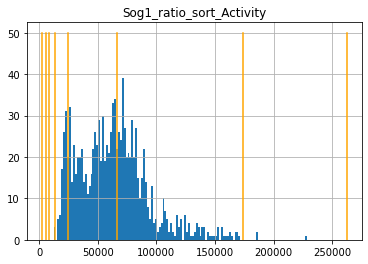

array([[<AxesSubplot:title={'center':'Sog1_ratio_sort_totalReads'}>]],
      dtype=object)

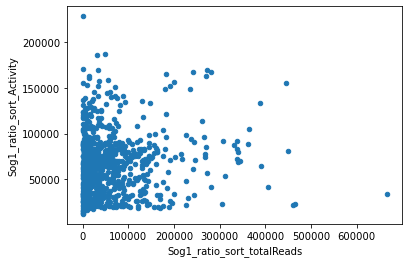

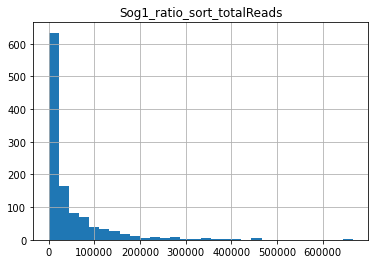

In [7]:
pd.DataFrame.hist(data=SC_Glucose,column='Sog1_ratio_sort_Activity',bins=130)
for val in BinValues:
    plt.plot([val,val],[0,50],c='orange')
plt.savefig('ActivityHist.pdf')
plt.show()

SC_Glucose.plot.scatter(y='Sog1_ratio_sort_Activity',x='Sog1_ratio_sort_totalReads')
# plt.savefig('Figures/ActivityHist.pdf')
SC_Glucose.corr()

pd.DataFrame.hist(data=SC_Glucose,column='Sog1_ratio_sort_totalReads',bins=30)

In [8]:
# merge dataframe and export
SC_Glucose.to_csv('../Data/Processed/Sog1_Ratio_BinCounts.csv')
masterDF = masterDF_original.drop(columns=['Barcode'])
masterDF['Activity_Sog1_ratio']=SC_Glucose.Sog1_ratio_sort_Activity
masterDF['TotalReads_Sog1_ratio']=SC_Glucose.Sog1_ratio_sort_totalReads
masterDF.to_csv('../Data/Processed/Sog1_Ratio_MasterDF_20220401.csv') # change date/name if needed

In [9]:
# how many Bins is each AD in? 
ReadCountColumns = ['MYS_1', 'MYS_2', 'MYS_3', 'MYS_4', 'MYS_5', 'MYS_6', 'MYS_7', 'MYS_8']
tempDF = np.matrix(SC_Glucose[ReadCountColumns])

for i, thresh in enumerate([1,10,100,1000]):
    plt.subplot(2,2,i+1)
    a = tempDF>thresh
    b = np.sum(a,axis=1)
    plt.hist(b,100),plt.title('Threshold = %i'%thresh)
plt.tight_layout()
plt.show()


KeyError: "None of [Index(['MYS_1', 'MYS_2', 'MYS_3', 'MYS_4', 'MYS_5', 'MYS_6', 'MYS_7', 'MYS_8'], dtype='object')] are in the [columns]"

In [ ]:
def plotHists(Core_Xvalue,masterDF,readthreshold,replicatelist=['A','B','C','D']):
    for j, replicate2 in enumerate(replicatelist):
        Xval = '%s%s'%(Core_Xvalue,replicate2)
        plt.subplot(2,len(replicatelist),1+j)
        indx = masterDF[Xval]>0
        temp =masterDF[indx]
        plt.hist(np.log10(temp[Xval]),50)
        plt.title(Xval + ' n = %i' %sum(indx))
        plt.plot([np.log10(readthreshold),np.log10(readthreshold)],[0,40])
    plt.tight_layout()
    plt.show()
